In [1]:
# Enable multiple outputs of a cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

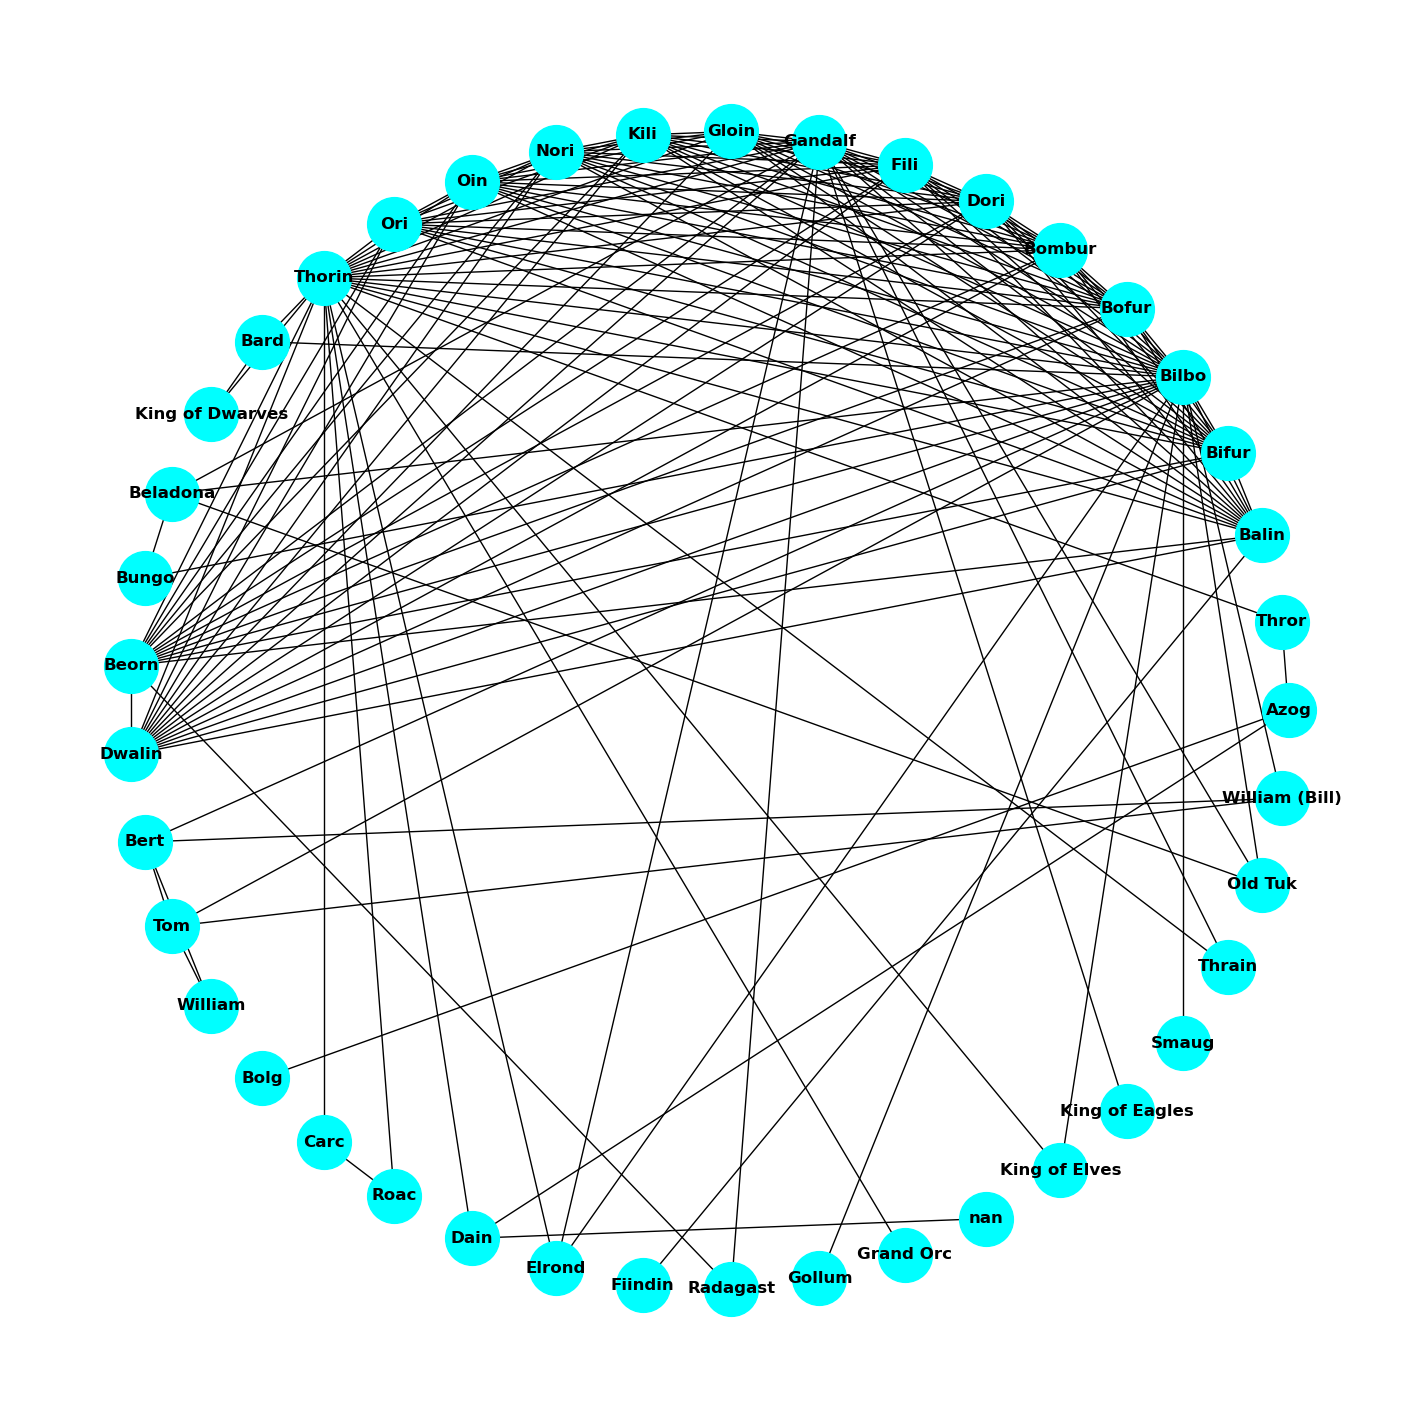

In [3]:
#import libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import statistics
# 1. LOAD THE RAW DATA
#We skip 42 row because it a name of character not a nodes or edges
df = pd.read_excel('../data/Hobbit_Data.xlsx',sheet_name='Sheet1') 
#Create empty network
G =nx.Graph()
#Add edges (the pair Source-Target in the dataframe)
G.add_edges_from([(row['Source'], row['Target']) for idx, row in df.iterrows()])
#Create a dict of name to map with the legend such as BI = Bilbo
name_map = {
    'AZ': 'Azog', 'BA': 'Balin', 'BD': 'Beladona', 'BE': 'Bert', 'BF': 'Bifur',
    'BI': 'Bilbo', 'BL': 'Bolg', 'BM': 'Bombur', 'BN': 'Beorn', 'BO': 'Bofur',
    'BR': 'Bard', 'BU': 'Bungo', 'CA': 'Carc', 'DA': 'Dain', 'DO': 'Dori',
    'DW': 'Dwalin', 'EL': 'Elrond', 'FI': 'Fili', 'FN': 'Fiindin', 'GA': 'Gandalf',
    'GC': 'Grand Orc', 'GL': 'Gloin', 'GO': 'Gollum', 'KA': 'King of Eagles',
    'KD': 'King of Dwarves', 'KE': 'King of Elves', 'KI': 'Kili', 'NA': 'Nain',
    'NO': 'Nori', 'OI': 'Oin', 'OR': 'Ori', 'OT': 'Old Tuk', 'RA': 'Radagast',
    'RO': 'Roac', 'SM': 'Smaug', 'TH': 'Thorin', 'TM': 'Tom', 'TO': 'Thror',
    'TR': 'Thrain', 'WB': 'William (Bill)', 'WI': 'William'
}
#Relebel the node to get full name.
G = nx.relabel_nodes(G, name_map)

#Draw the network
figure = plt.gcf()
pos = nx.circular_layout(G)#Position all node
nx.draw(G,pos, with_labels=True, node_color = 'cyan',font_weight='bold', node_size = 1500)
 #Tune different size of a figure and make it clear. 
figure.set_size_inches(14, 14)

plt.savefig("networkx_hobbot.png")

#### Density

In [4]:
#Compute the density
density_G=nx.density(G)
#print and compute number of node (numbers of characters) and number of edge (connections)
print("The number of nodes (characters) in G is: ", len(list(G.nodes)))
print("The number of edges (connections) in G is: ", len(list(G.edges)))
print("Network Density is",density_G)
n = len(list(G.nodes)) #n is the number of nodes
print("The maximum possible numbeer of egdes of G is:", int(n*(n-1)/2))
#The network density is 0.195 (19.5%). This means that out of every possible character pairing in The Hobbit, only 19.5% of them actually met or interacted with each other in the story

The number of nodes (characters) in G is:  41
The number of edges (connections) in G is:  160
Network Density is 0.1951219512195122
The maximum possible numbeer of egdes of G is: 820


#### Degree Centrality

In [5]:
#Compute the degree centrality of nodes in the network G
degree_G = G.degree()
print("The degrees of every node in G are ", degree_G)

The degrees of every node in G are  [('Azog', 3), ('Thror', 2), ('Balin', 16), ('Bifur', 15), ('Bilbo', 26), ('Bofur', 15), ('Bombur', 15), ('Dori', 15), ('Fili', 15), ('Gandalf', 21), ('Gloin', 13), ('Kili', 15), ('Nori', 15), ('Oin', 15), ('Ori', 14), ('Thorin', 25), ('Bard', 3), ('King of Dwarves', 2), ('Beladona', 4), ('Bungo', 2), ('Beorn', 15), ('Dwalin', 15), ('Bert', 4), ('Tom', 4), ('William', 2), ('Bolg', 1), ('Carc', 2), ('Roac', 2), ('Dain', 3), ('Elrond', 3), ('Fiindin', 1), ('Radagast', 2), ('Gollum', 1), ('Grand Orc', 1), (nan, 1), ('King of Elves', 2), ('King of Eagles', 1), ('Smaug', 1), ('Thrain', 2), ('Old Tuk', 3), ('William (Bill)', 3)]


In [6]:
#Compute mean degree of G
n1=len(list(G.nodes))#n1 is the number of nodes of G1
#########
#Compute the mean degrees of G
mean_degree_G = sum(dict(degree_G).values())/n1 
#Print out the mean degrees of G1 and G2
print("The mean degree of G is ", mean_degree_G)

#The network has a mean degree of 7.8, which mean that an average character in The Hobbit interacts with around 8 other individuals.
#So character that has degree more than 7.8 is a main character

The mean degree of G is  7.804878048780488


In [7]:
#compute degree centrality distribution for each node
centrality = nx.degree_centrality(G)
degree_distribution_list = list(centrality.values()) # a list of the degree frequency values

In [8]:
# Degree distribution of G
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)

# Obtain unique degree values and their counts
degree_unique = np.unique(degree_sequence, return_counts=True)

# Prepare the dataframe (degree and frequency)
degree_plot = list(range(0, max(degree_unique[0]) + 1))
freq_plot = [0] * len(degree_plot)

for i in degree_unique[0]:
    freq_plot[i] = degree_unique[-1][list(degree_unique[0]).index(i)]

# Create dataframe
d = {
    'degree': degree_plot,
    'frequency': [f/sum(freq_plot) for f in freq_plot]
}

df_G = pd.DataFrame(data=d)

df_G

,degree,frequency
0,0,0.000000
1,1,0.170732
2,2,0.219512
3,3,0.146341
4,4,0.073171
5,5,0.000000
6,6,0.000000
7,7,0.000000
8,8,0.000000
9,9,0.000000


<BarContainer object of 27 artists>

Text(0.5, 0, 'Degree')

Text(0, 0.5, 'Frequency')

Text(0.5, 1.0, 'Degree Centrality Distribution Plot')

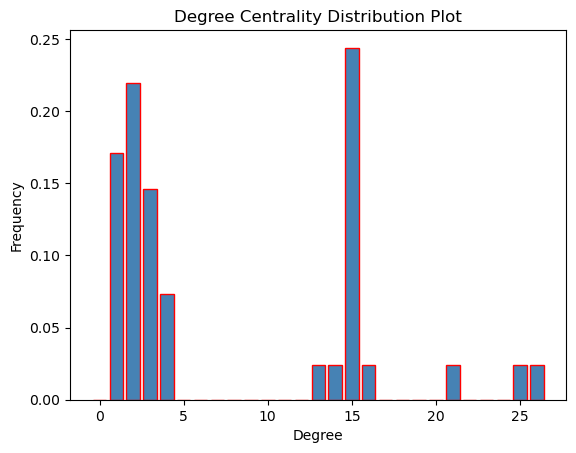

In [25]:
# plotting the Degree Centrality distribution
plt.bar(df_G['degree'], df_G['frequency'], color = "steelblue", edgecolor = 'red')
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Centrality Distribution Plot")
plt.savefig("Degree_plot.jpg")

#### K-core

In [10]:
# get the core value for each node in the network
core_n = nx.core_number(G)
core_n

{'Azog': 2,
 'Thror': 2,
 'Balin': 14,
 'Bifur': 14,
 'Bilbo': 14,
 'Bofur': 14,
 'Bombur': 14,
 'Dori': 14,
 'Fili': 14,
 'Gandalf': 14,
 'Gloin': 13,
 'Kili': 14,
 'Nori': 14,
 'Oin': 14,
 'Ori': 14,
 'Thorin': 14,
 'Bard': 2,
 'King of Dwarves': 2,
 'Beladona': 3,
 'Bungo': 2,
 'Beorn': 14,
 'Dwalin': 14,
 'Bert': 3,
 'Tom': 3,
 'William': 2,
 'Bolg': 1,
 'Carc': 2,
 'Roac': 2,
 'Dain': 2,
 'Elrond': 3,
 'Fiindin': 1,
 'Radagast': 2,
 'Gollum': 1,
 'Grand Orc': 1,
 nan: 1,
 'King of Elves': 2,
 'King of Eagles': 1,
 'Smaug': 1,
 'Thrain': 2,
 'Old Tuk': 3,
 'William (Bill)': 3}

In [11]:
# print out the nodes with the maximim cores
max_core = max(core_n.values())
core_node = [node for node, core in core_n.items() if core == max_core]
print("Maximum core value in the network:", max_core)
print("----------")
print("Nodes belonging to the maximum core in the network:\n", list(core_node))

Maximum core value in the network: 14
----------
Nodes belonging to the maximum core in the network:
 ['Balin', 'Bifur', 'Bilbo', 'Bofur', 'Bombur', 'Dori', 'Fili', 'Gandalf', 'Kili', 'Nori', 'Oin', 'Ori', 'Thorin', 'Beorn', 'Dwalin']


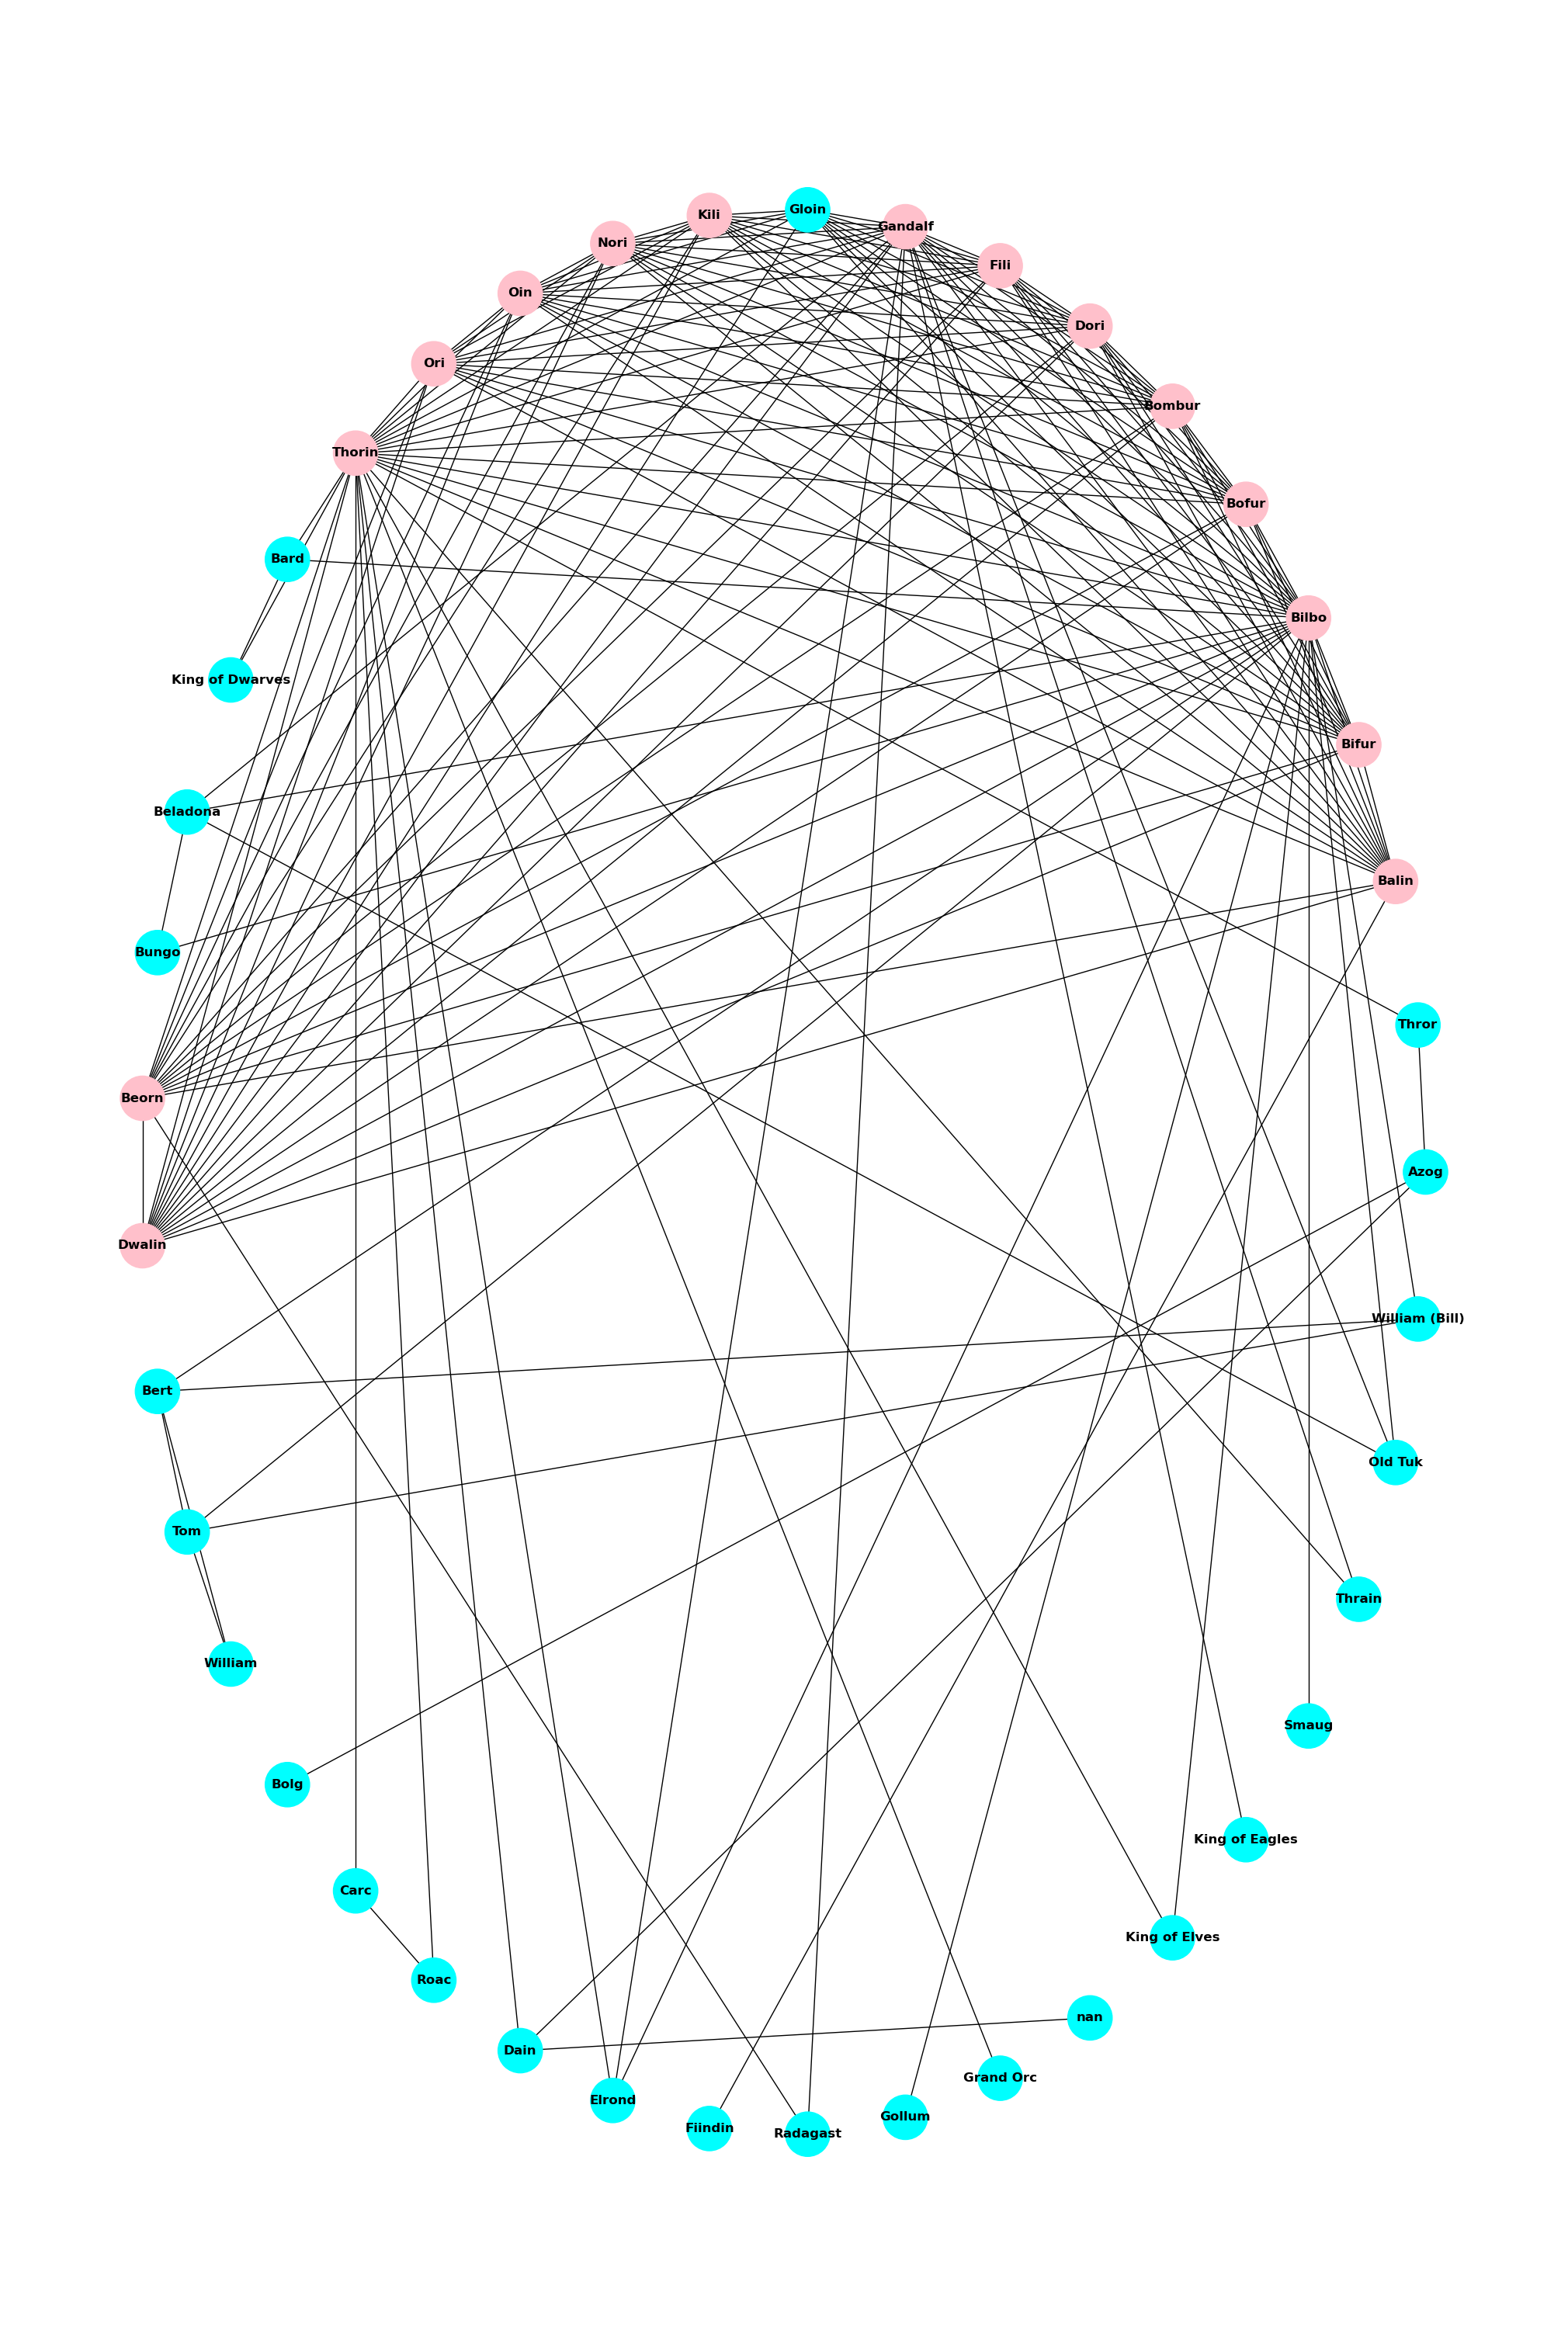

In [12]:
core = dict(core_n)
#Returns the main core i.e the core with the largest degree
main_core = set(nx.k_core(G))
nodes = list(G.nodes())

indices = []
for i in range(0, len(nodes)):
    if nodes[i] in main_core:
        indices.append(i)
        
#all_indexes
node_color = ['cyan'] * G.number_of_nodes() # all the nodes are plotted by cyan 
node_color = np.array(node_color)
node_color[indices] = "pink" #highlights the node in the main core using red
node_color = node_color.tolist()

#visualize the network
figure = plt.gcf()
pos = nx.circular_layout(G)#Position all node
nx.draw(G, pos, with_labels = True, node_color = node_color, font_weight = 'bold', node_size = 1700)
figure.set_size_inches(20,30)
plt.savefig("k-core.jpg")




In [13]:
#computuing the mean, median and range for k-core
kc_value = core.values()
k_core_mean = sum(kc_value) / len(kc_value)
k_core_range = max(kc_value) - min(kc_value)
k_core_median = statistics.median(kc_value)
print("the mean of the k_cores:", k_core_mean)
print("the range of the k_cores:", k_core_range)
print("the median of the k_cores:", k_core_median)

the mean of the k_cores: 6.634146341463414
the range of the k_cores: 13
the median of the k_cores: 3


(array([ 7., 12.,  6.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
        15.]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15.]),
 <BarContainer object of 14 artists>)

Text(0.5, 0, 'k-core value')

Text(0, 0.5, 'nodes frequency')

Text(0.5, 1.0, 'k-core values distribution plot')

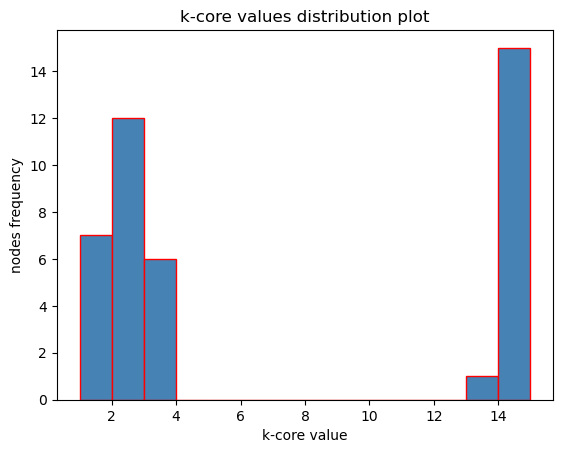

In [26]:
# plotting the k core value distribution
core_values = list(core_n.values())
plt.hist(core_values, bins=range(min(core_values), max(core_values)+2), color = "steelblue", edgecolor = 'red')
plt.xlabel("k-core value")
plt.ylabel("nodes frequency")
plt.title("k-core values distribution plot")

plt.savefig("k-core_plot.png")

From the plot above, we deduce that the nodes in k = 1-3 are loosely connected to each other abd they are assumely the minor character in the hobbit interact, also we have 15 nodes present in the 14 core, it shows that the nodes present in this core are fully connected to each other. In conclusion, we can say that the main character appear together frequently compared to the minor characters, and most of the time the minor character do connect to the main character in the hobbit interaction.

#### Closeness Centrality

In [15]:
#Compute closeness centrality
closeness=dict(nx.closeness_centrality(G))
print("The closeness centrality of each node:", closeness)
print("\n")
max(closeness.values()) #--- thorin

The closeness centrality of each node: {'Azog': 0.32, 'Thror': 0.43478260869565216, 'Balin': 0.5797101449275363, 'Bifur': 0.5714285714285714, 'Bilbo': 0.6896551724137931, 'Bofur': 0.5714285714285714, 'Bombur': 0.5714285714285714, 'Dori': 0.5714285714285714, 'Fili': 0.5714285714285714, 'Gandalf': 0.625, 'Gloin': 0.5555555555555556, 'Kili': 0.5714285714285714, 'Nori': 0.5714285714285714, 'Oin': 0.5714285714285714, 'Ori': 0.5633802816901409, 'Thorin': 0.7017543859649122, 'Bard': 0.47058823529411764, 'King of Dwarves': 0.42105263157894735, 'Beladona': 0.43956043956043955, 'Bungo': 0.4166666666666667, 'Beorn': 0.5714285714285714, 'Dwalin': 0.5714285714285714, 'Bert': 0.43010752688172044, 'Tom': 0.43010752688172044, 'William': 0.3053435114503817, 'Bolg': 0.24390243902439024, 'Carc': 0.42105263157894735, 'Roac': 0.42105263157894735, 'Dain': 0.4444444444444444, 'Elrond': 0.4819277108433735, 'Fiindin': 0.37037037037037035, 'Radagast': 0.39215686274509803, 'Gollum': 0.41237113402061853, 'Grand O

0.7017543859649122

In [16]:
#computuing the mean, median and range
close_value = closeness.values()
closeness_mean = sum(close_value) / len(close_value)
closeness_range = max(close_value) - min(close_value)
closeness_median = statistics.median(close_value)
print("the mean of the closeness centrality:", closeness_mean)
print("the range of the closeness centrality:", closeness_range)
print("the median of the closeness centrality:", closeness_median)

the mean of the closeness centrality: 0.47749474886105364
the range of the closeness centrality: 0.457851946940522
the median of the closeness centrality: 0.43956043956043955


(array([ 1.,  3.,  0.,  3., 10.,  7.,  1.,  0., 13.,  1.,  0.,  2.]),
 array([0.24390244, 0.28205677, 0.3202111 , 0.35836543, 0.39651975,
        0.43467408, 0.47282841, 0.51098274, 0.54913707, 0.5872914 ,
        0.62544573, 0.66360006, 0.70175439]),
 <BarContainer object of 12 artists>)

Text(0.5, 0, 'Closeness-centrality')

Text(0, 0.5, 'nodes-frequency')

Text(0.5, 1.0, 'Closeness - Distribution plot')

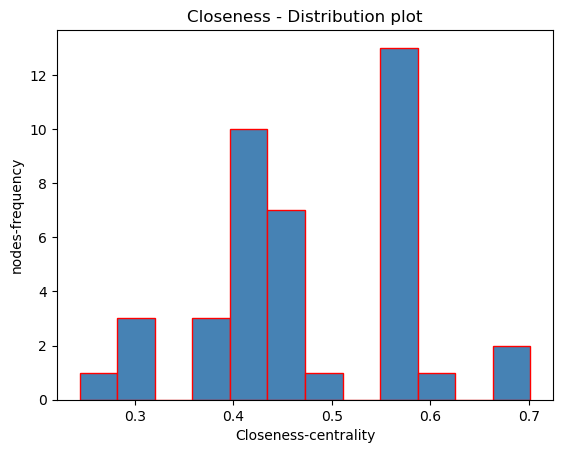

In [27]:
# plotting the closeness distribution
plt.hist(closeness.values(), bins=12, color = "steelblue", edgecolor = 'red')
plt.xlabel("Closeness-centrality")
plt.ylabel("nodes-frequency")
plt.title("Closeness - Distribution plot")

plt.savefig("Closeness_plot.png")

From the plot above, we can deduce that closeness centrality at 0-3 has a low node frequency, we can also see a major increase the number of nodes frequency around 0.55 - 0.57 which indicates closeness central in terms of distance and we have just few node at 0.67-7 which are centra in terms of distance. In conclusion, we can say that the nodes with higher closeness(Thorin and Bilbo) can reach evevry other character qucickly compared to nodes with lower closeness.

#### Betweenness centrality

In [18]:
#Compute betweeness centrality
betweenness=dict(nx.betweenness_centrality(G))
print("The betweenness centrality of each node:\n ", betweenness)
print("\n")
print("The maximum_betweeness in the network is:", max(betweenness.values())) #--- thorin

The betweenness centrality of each node:
  {'Azog': 0.05128205128205128, 'Thror': 0.046153846153846156, 'Balin': 0.05019723865877712, 'Bifur': 0.00019723865877712034, 'Bilbo': 0.3788297172912557, 'Bofur': 0.00019723865877712034, 'Bombur': 0.00019723865877712034, 'Dori': 0.00019723865877712034, 'Fili': 0.00019723865877712034, 'Gandalf': 0.13246219592373437, 'Gloin': 0.0, 'Kili': 0.00019723865877712034, 'Nori': 0.00019723865877712034, 'Oin': 0.00019723865877712034, 'Ori': 0.0, 'Thorin': 0.4307527942143326, 'Bard': 0.005982905982905983, 'King of Dwarves': 0.0, 'Beladona': 0.0027777777777777783, 'Bungo': 0.0, 'Beorn': 0.0202991452991453, 'Dwalin': 0.00019723865877712034, 'Bert': 0.02435897435897436, 'Tom': 0.02435897435897436, 'William': 0.0, 'Bolg': 0.0, 'Carc': 0.0, 'Roac': 0.0, 'Dain': 0.09615384615384616, 'Elrond': 0.0, 'Fiindin': 0.0, 'Radagast': 0.0, 'Gollum': 0.0, 'Grand Orc': 0.0, nan: 0.02564102564102564, 'King of Elves': 0.0, 'King of Eagles': 0.0, 'Smaug': 0.0, 'Thrain': 0.0, 'O

In [19]:
#computuing the mean, median and range
between_value = betweenness.values()
betweenness_mean = sum(between_value) / len(between_value)
betweenness_range = max(between_value) - min(between_value)
betweenness_median = statistics.median(between_value)
print("the mean of the betweeness centrality:", betweenness_mean)
print("the range of the betweeness centrality:", betweenness_range)
print("the median of the betweeness centrality:", betweenness_median)


the mean of the betweeness centrality: 0.03148843026891807
the range of the betweeness centrality: 0.4307527942143326
the median of the betweeness centrality: 0.00019723865877712034


(array([34.,  3.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  1.]),
 array([0.        , 0.02871685, 0.05743371, 0.08615056, 0.11486741,
        0.14358426, 0.17230112, 0.20101797, 0.22973482, 0.25845168,
        0.28716853, 0.31588538, 0.34460224, 0.37331909, 0.40203594,
        0.43075279]),
 <BarContainer object of 15 artists>)

Text(0.5, 0, 'Betweeness-centrality')

Text(0, 0.5, 'nodes-frequency')

Text(0.5, 1.0, 'Betweeness - Distribution plot')

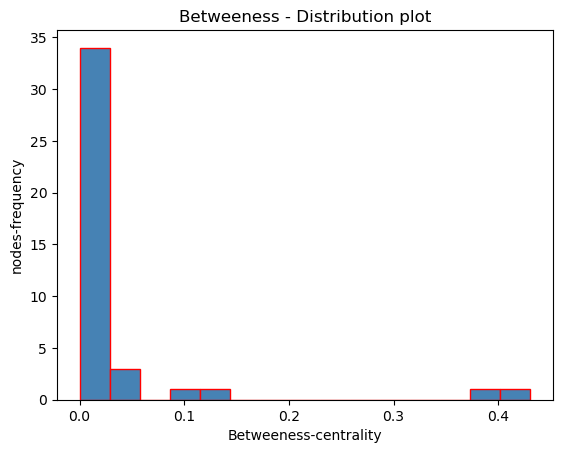

In [28]:
# plotting the betweeness distribution
plt.hist(betweenness.values(), bins=15, color = "steelblue", edgecolor = 'red')
plt.xlabel("Betweeness-centrality")
plt.ylabel("nodes-frequency")
plt.title("Betweeness - Distribution plot")

plt.savefig("Betweeness_plot.png")


From the plot above we can deduce that we only have few number of nodes  which has betweenessess value of 0.35+ and other nodes are between 0 and 0.15. This tells us that the nodes with 0.35+ can control communications in this network and removing them may lead to reduced efficiency of this network, also the nodes with betweeness values from 0 and 0.15 are not influential over network flow

Degree Centrality: tell us what is the most important node which get most connection so our result is Bilbo with 26 degree which indicate that he is the most outstanding protagonist that intereacting with most chartacters throughout the story.

Closeness Centrality: tell us how close node is to all other node based on the shortest paths in the network. Our result shows Thorin has the highest Closeness Centrality at 0.702. This indicates that he is the most mathematically 'central' character in terms of distance, meaning he can reach other characters the fastest or spread information most quickly across the network

Betweeness Centrality: tell us which node are the"bridges" or "connectors" within the network. It measures how often a specific node lies on the shortest path between any two other nodes that are trying to reach each other our result shows Thorin has the highest Betweenness Centrality at 0.431. that mean he is for nearly 43% of all character-to-character pairs in the story, Thorin is the "middle-man" they must go through to be connected.

K-Component

In [21]:
components= nx.k_components(G)
components = dict(components)
print("K-components and their number of cores:\n")
print(components)
print("\n")

#compute the number of k-components with maximum k
print("Number of k-components with maximum k: ", len(components.get(max(components))))


K-components and their number of cores:

{14: [{'Dwalin', 'Dori', 'Oin', 'Gandalf', 'Thorin', 'Nori', 'Beorn', 'Bifur', 'Bombur', 'Kili', 'Ori', 'Bofur', 'Fili', 'Bilbo', 'Balin'}], 13: [{'Dwalin', 'Dori', 'Oin', 'Thorin', 'Bifur', 'Ori', 'Bofur', 'Gloin', 'Balin', 'Gandalf', 'Nori', 'Beorn', 'Bombur', 'Kili', 'Fili', 'Bilbo'}], 12: [{'Dwalin', 'Dori', 'Oin', 'Thorin', 'Bifur', 'Ori', 'Bofur', 'Gloin', 'Balin', 'Gandalf', 'Nori', 'Beorn', 'Bombur', 'Kili', 'Fili', 'Bilbo'}], 11: [{'Dwalin', 'Dori', 'Oin', 'Thorin', 'Bifur', 'Ori', 'Bofur', 'Gloin', 'Balin', 'Gandalf', 'Nori', 'Beorn', 'Bombur', 'Kili', 'Fili', 'Bilbo'}], 10: [{'Dwalin', 'Dori', 'Oin', 'Thorin', 'Bifur', 'Ori', 'Bofur', 'Gloin', 'Balin', 'Gandalf', 'Nori', 'Beorn', 'Bombur', 'Kili', 'Fili', 'Bilbo'}], 9: [{'Dwalin', 'Dori', 'Oin', 'Thorin', 'Bifur', 'Ori', 'Bofur', 'Gloin', 'Balin', 'Gandalf', 'Nori', 'Beorn', 'Bombur', 'Kili', 'Fili', 'Bilbo'}], 8: [{'Dwalin', 'Dori', 'Oin', 'Thorin', 'Bifur', 'Ori', 'Bofur', 'Gloin', 

#### Cliques

In [22]:
# Find all cliques in the network
cliques = list(nx.find_cliques(G))  # Returns a list of lists, each list is a clique

# Convert to a dictionary with clique size as key and list of cliques of that size as value
from collections import defaultdict

clique_dict = defaultdict(list)
for clique in cliques:
    clique_dict[len(clique)].append(clique)

print("Cliques grouped by size:\n")
for size in sorted(clique_dict.keys(), reverse=True):
    print(f"Size {size} cliques: {len(clique_dict[size])} cliques")

print("\n")

# Compute the number of maximum size cliques
max_clique_size = max(clique_dict.keys())
print(f"Number of cliques with maximum size ({max_clique_size}): {len(clique_dict[max_clique_size])}")

Cliques grouped by size:

Size 15 cliques: 1 cliques
Size 14 cliques: 1 cliques
Size 4 cliques: 3 cliques
Size 3 cliques: 8 cliques
Size 2 cliques: 11 cliques


Number of cliques with maximum size (15): 1


In [23]:
#find out the nodes with maximum values of the degree, closeness, and betweenness
#normalized values
degrees=dict(nx.degree_centrality(G))
max_degree=max(degrees.values())
max_closeness=max(closeness.values())
max_betweenness=max(betweenness.values())

max_degree_key=[items for items, value in degrees.items() 
                if value == max(degrees.values())]
max_closeness_key=[items for items, value in closeness.items() 
                if value == max(closeness.values())]
max_betweenness_key=[items for items, value in betweenness.items() 
                if value == max(betweenness.values())]

print("The nodes (character) with maximum degrees is ", max_degree_key, 
      ". The maximum degree is", max_degree)
print("------------------")
print("The nodes (character)  with maximum closeness centrality is ", max_closeness_key, 
      ". The maximum closeness centrality is", max_closeness)
print("-------------------")
print("The nodes (character)  with maximum betweenness centrality is ", max_betweenness_key, 
      ". The maximum betweenness centrality is", max_betweenness)

The nodes (character) with maximum degrees is  ['Bilbo'] . The maximum degree is 0.65
------------------
The nodes (character)  with maximum closeness centrality is  ['Thorin'] . The maximum closeness centrality is 0.7017543859649122
-------------------
The nodes (character)  with maximum betweenness centrality is  ['Thorin'] . The maximum betweenness centrality is 0.4307527942143326
